<a href="https://colab.research.google.com/github/gunaanand08/Ioe/blob/main/Experiment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset
   Motor_Temperature  Vibration  Current  Voltage   RPM
0               61.5       1.25     14.2      229  1480
1               62.1       1.28     14.4      230  1485
2               61.8       1.31     14.5      231  1482
3               62.6       1.29     14.3      229  1488
4               63.0       1.35     14.8      228  1492

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Motor_Temperature  20 non-null     float64
 1   Vibration          20 non-null     float64
 2   Current            20 non-null     float64
 3   Voltage            20 non-null     int64  
 4   RPM                20 non-null     int64  
dtypes: float64(3), int64(2)
memory usage: 932.0 bytes
None

Missing Values
Motor_Temperature    0
Vibration            0
Current              0
Voltage              0
RPM                 

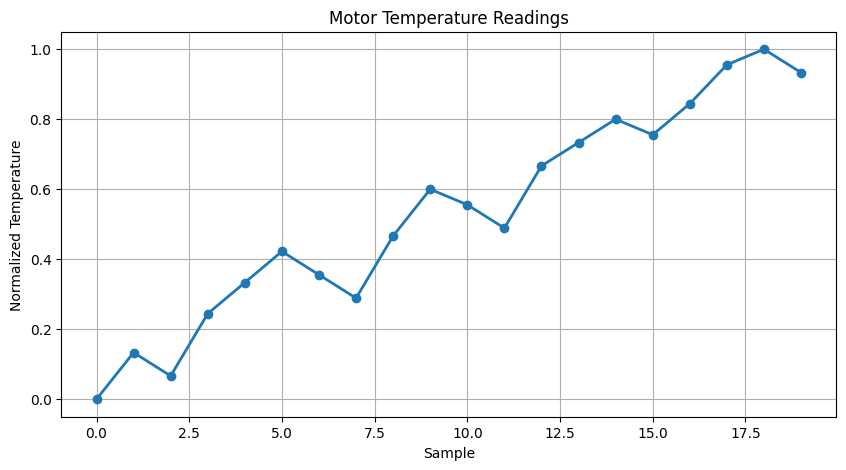

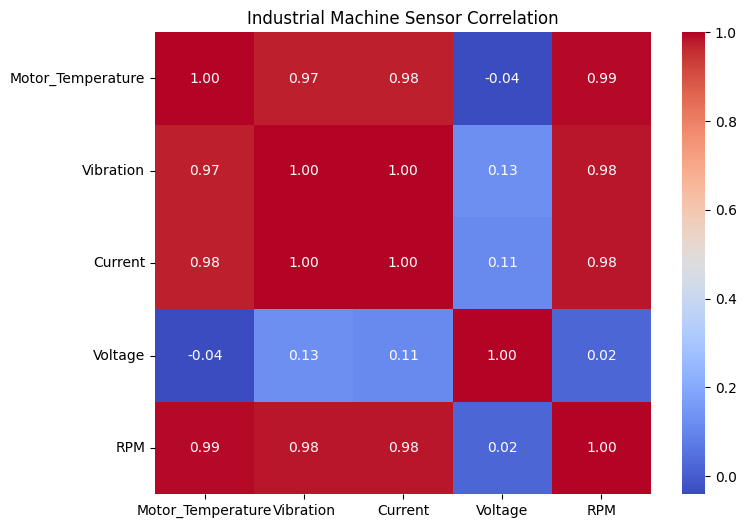

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# =====================================================
# Industrial Machine Health Monitoring Dataset
# =====================================================

data = {
    "Motor_Temperature": [61.5, 62.1, 61.8, 62.6, 63.0, 63.4, 63.1, 62.8, 63.6, 64.2,
                          64.0, 63.7, 64.5, 64.8, 65.1, 64.9, 65.3, 65.8, 66.0, 65.7],

    "Vibration": [1.25, 1.28, 1.31, 1.29, 1.35, 1.38, 1.36, 1.40, 1.43, 1.46,
                  1.44, 1.42, 1.47, 1.51, 1.55, 1.53, 1.58, 1.60, 1.57, 1.54],

    "Current": [14.2, 14.4, 14.5, 14.3, 14.8, 15.0, 14.9, 15.1, 15.3, 15.5,
                15.4, 15.2, 15.6, 15.8, 16.0, 15.9, 16.1, 16.3, 16.2, 16.0],

    "Voltage": [229, 230, 231, 229, 228, 230, 231, 232, 231, 230,
                229, 228, 229, 230, 231, 232, 231, 230, 229, 228],

    "RPM": [1480, 1485, 1482, 1488, 1492, 1495, 1493, 1490, 1498, 1502,
            1500, 1497, 1504, 1506, 1510, 1508, 1512, 1515, 1513, 1510]
}

df = pd.DataFrame(data)

print("Original Dataset")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Normalize data
scaler = MinMaxScaler()
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nNormalized Dataset")
print(df.head())

# Save cleaned dataset
df.to_csv("clean_machine_data.csv", index=False)

# ----------------------------
# Motor Temperature Plot
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(df["Motor_Temperature"], marker='o', linewidth=2)
plt.title("Motor Temperature Readings")
plt.xlabel("Sample")
plt.ylabel("Normalized Temperature")
plt.grid(True)
plt.show()

# ----------------------------
# Correlation Heatmap
# ----------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Industrial Machine Sensor Correlation")
plt.show()